# Attention prior for DeltaNMF

Design doc: [`idea.md`](../idea.md).

## What is new vs what is reused

| Piece | Source | Role |
|---|---|---|
| **Embedding-NMF** | [DeltaNMF](../third_party/deltanmf) | Baseline: scGPT embeddings → `S_E` → graph-regularized NMF |
| **`S_E` construction** | [DeltaNMF scGPT script](../third_party/deltanmf/resources/scgpt/create_transformer_similarity_matrix_scgpt.py) | `model.encoder` → corrcoef → ReLU |
| **NMF pipeline** | `deltanmf.api.run_onestage_deltanmf` (as in DeltaNMF's `run_onestage.py`) | Same pipeline for every arm |
| **scGPT model** | [scGPT](../third_party/scGPT) `TransformerModel` + pretrained checkpoint | Frozen; loaded by [`scgpt_attention.py`](../src/attn_enhance/scgpt_attention.py) |
| **Attention → `S_att`** | scGPT's `Tutorial_Attention_GRN` recipe, then symmetrize + $k$NN | **Novel prior** |
| **Attention-NMF / Combined** | this project | Same DeltaNMF pipeline; swap / mix `S_E` ← `S_att` |

## Mental model

```
X (cells × genes)
        │
        ├─► frozen scGPT embeddings ──► S_E      ──┐
        │                                          ├─► DeltaNMF        ──► W, H
        └─► frozen scGPT attention  ──► S_att ────┘   (run_onestage_deltanmf)
```

**Question:** does contextual `S_att` change recovered programs relative to DeltaNMF’s static `S_E`?

This notebook walks the pipeline with **intermediate visuals** so you can see the data at each stage — not only the final bar chart.

> On synthetic $X$ this is **pipeline visualization**. Biological claims need real data + markers/pathways ([idea.md](../idea.md) §17-D).

## 0. Setup

Kernel: **Python (attention)**. We put `src/` and vendored DeltaNMF on `sys.path`, then import helpers.

What each import is for:
- `genes_from_scgpt_vocab` / `make_synthetic_expression` — build a toy $X$ scGPT can tokenize
- `extract_scgpt_priors` — frozen checkpoint → `S_E` and `S_att`
- `load_pretrained_scgpt` — scGPT's own `TransformerModel` with the checkpoint weights (used to verify the layer in §2)
- `run_program_discovery_experiment` — four-arm matrix + $\alpha$ sweep, each arm one `run_onestage_deltanmf` call
- `plot_*` — intermediate and comparison figures

In [1]:
from __future__ import annotations

import copy
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from einops import rearrange
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "third_party" / "deltanmf"))
sys.path.insert(0, str(ROOT / "third_party" / "scGPT"))

from attn_enhance import (
    genes_from_scgpt_vocab,
    make_synthetic_expression,
    extract_scgpt_priors,
    load_pretrained_scgpt,
    paper_attention_map,
    tokenize_cells,
    rank_normalize_attention,
    fit_deltanmf,
    graph_laplacian,
    graph_smoothness,
    run_program_discovery_experiment,
    format_comparison,
    DEFAULT_ALPHAS,
    top_edges,
    plot_synthetic_atlas,
    plot_prior_edge_diagnostics,
    plot_prior_comparison,
    plot_recon_comparison,
    plot_program_loadings,
    plot_top_genes_comparison,
    plot_cell_program_usage,
    plot_arm_W_similarity,
)
from scgpt.utils import set_seed

SCGPT_DIR = ROOT / "checkpoints" / "scgpt"
for f in ("best_model.pt", "vocab.json", "args.json"):
    if not (SCGPT_DIR / f).exists():
        raise FileNotFoundError(f"Missing {SCGPT_DIR / f}")

print("project:", ROOT)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")
print("checkpoint:", SCGPT_DIR)

project: /Users/albert/Documents/attention
device: cpu
checkpoint: /Users/albert/Documents/attention/checkpoints/scgpt


## 1. Expression matrix $X$

DeltaNMF / NMF factorize

$$
X \approx WH,
\qquad W\in\mathbb{R}_+^{G\times K}\ (\text{gene–program loadings}),
\quad H\in\mathbb{R}_+^{K\times N}\ (\text{program activity per cell}).
$$

Until a real cohort is plugged in ([idea.md](../idea.md) §15), we use a **small synthetic** atlas:

1. Gene symbols come from the scGPT vocab (placeholders like `G000` cannot be tokenized by a real checkpoint).
2. We **plant** $K$ gene programs (`program_W`, `program_H`) and form $X \approx W H$ + noise.
3. The figures below show what the model will see (`X`) and the ground-truth factors (for sanity only — not available on real data).

> Later: replace with AnnData —  
> `X = np.asarray(adata.X.todense() if hasattr(adata.X, "todense") else adata.X)`  
> `names = list(adata.var_names)`.

X shape (cells × genes): (80, 48)
genes: ['CD3D', 'CD3E', 'CD8A', 'CD4', 'MS4A1', 'CD79A', 'NKG7', 'GNLY', 'LYZ', 'S100A8'] ...
planted W: (48, 4) | planted H: (80, 4)
X range: [0.000, 2.369]  mean=0.393
  planted program 0: 10 genes → ['CD3D', 'CD3E', 'CD8A', 'CD4', 'MS4A1'] ...
  planted program 1: 12 genes → ['LYZ', 'S100A8', 'S100A9', 'CST3', 'FCGR3A'] ...
  planted program 2: 12 genes → ['IL7R', 'CCR7', 'GZMB', 'PRF1', 'CCL5'] ...
  planted program 3: 12 genes → ['STAT1', 'IRF7', 'ACTB', 'GAPDH', 'B2M'] ...


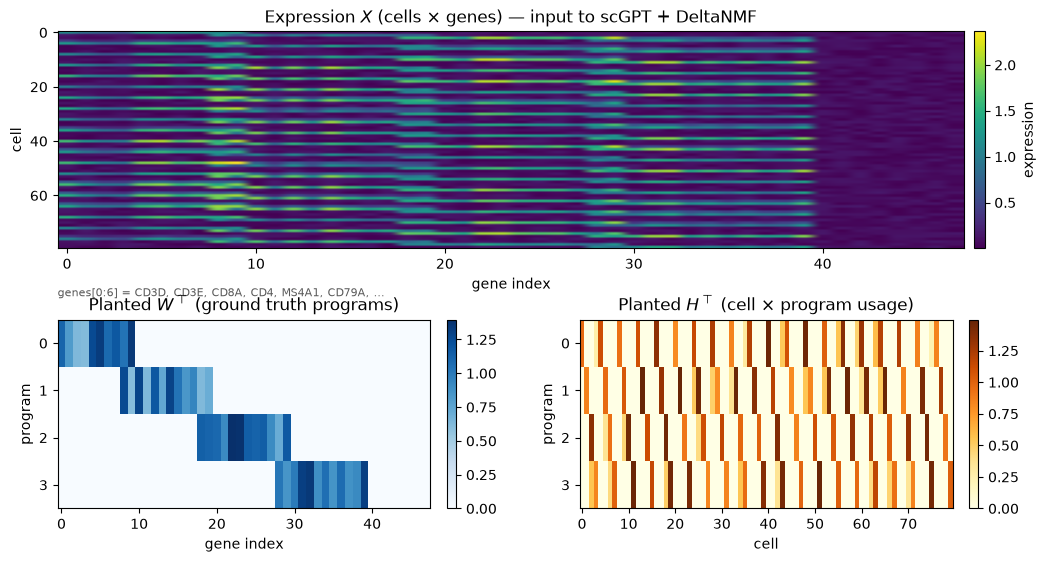

In [2]:
N_GENES, N_CELLS, K = 48, 80, 4
names = genes_from_scgpt_vocab(SCGPT_DIR, n_genes=N_GENES, seed=0)
atlas = make_synthetic_expression(
    n_cells=N_CELLS, n_genes=N_GENES, n_programs=K, gene_names=names, seed=0
)
X = atlas.X

print("X shape (cells × genes):", X.shape)
print("genes:", names[:10], "...")
print("planted W:", atlas.program_W.shape, "| planted H:", atlas.program_H.shape)
print("X range: [{:.3f}, {:.3f}]  mean={:.3f}".format(X.min(), X.max(), X.mean()))
for k, idxs in enumerate(atlas.program_gene_sets):
    print(f"  planted program {k}: {len(idxs)} genes →", [names[i] for i in idxs[:5]], "...")

plot_synthetic_atlas(X, atlas.program_W, atlas.program_H, gene_names=names)
plt.show()

### What to look for in the atlas figure

| Panel | What it shows | Why it matters |
|---|---|---|
| **$X$** | Observed expression | This is the only matrix DeltaNMF reconstructs |
| **Planted $W^\top$** | Blocky gene membership | Ground truth for later “did we recover programs?” checks |
| **Planted $H^\top$** | Which cells use which program | Explains the striped / blocky look in $X$ |

Gene *symbols* look biological (immune markers) because we sampled real vocab names; the *expression pattern* is still synthetic.

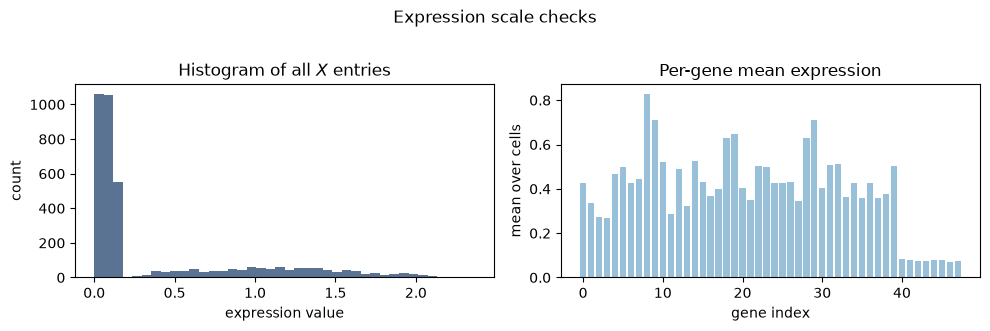

In [3]:
# Extra intermediate view: expression distribution + per-gene means.
# Helps confirm X is non-negative and not pathological before loading scGPT.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].hist(X.ravel(), bins=40, color="#3d5a80", alpha=0.85)
axes[0].set_xlabel("expression value")
axes[0].set_ylabel("count")
axes[0].set_title(r"Histogram of all $X$ entries")

gene_mean = X.mean(axis=0)
axes[1].bar(np.arange(len(gene_mean)), gene_mean, color="#98c1d9")
axes[1].set_xlabel("gene index")
axes[1].set_ylabel("mean over cells")
axes[1].set_title("Per-gene mean expression")

fig.suptitle("Expression scale checks", y=1.02)
fig.tight_layout()
plt.show()

## 2. Build the two gene–gene priors

Both priors are $G\times G$ similarity graphs over the **same** gene set. Only the *source* of edges differs.

### $S_E$ — DeltaNMF default (static)

$$
e_i = \texttt{model.encoder}(\text{gene}_i),
\qquad
S_E{ij} = \max\bigl(0,\operatorname{corr}(e_i,e_j)\bigr).
$$

Interpretation: genes with similar **pretrained embeddings** are linked. No dependence on this dataset’s expression beyond which genes are present.

### $S^{att}$ — novel (contextual), from scGPT's own attention layers

The model is scGPT's `TransformerModel` from `third_party/scGPT`, built with the same arguments as DeltaNMF's `S_E` script and scGPT's Attention-GRN tutorial: 512-d embeddings, 12 blocks × 8 heads, feed-forward size 512, post-LayerNorm, ReLU. Each block computes

$$
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\!\Bigl(\frac{QK^\top}{\sqrt d}\Bigr)V,
\qquad Q=hW_q,\ K=hW_k,\ V=hW_v,\ d=64.
$$

Every gene in our cells is observed, so no attention mask applies (full self-attention).

> **Why rename two keys?** The checkpoint was trained with flash-attn, which stores each block's packed Q/K/V projection as `Wqkv`. flash-attn needs CUDA, so on a Mac `TransformerModel` builds PyTorch's `nn.TransformerEncoderLayer`, which stores the same packed projection as `in_proj_weight`. scGPT's own loading code keeps only keys whose names match, so it would silently leave all 12 attention blocks random. We rename `Wqkv` → `in_proj` and refuse to load if any encoder or transformer weight is missing. `tests/test_scgpt_attention.py` checks that PyTorch's attention with the renamed weights equals the flash-attn formula on the real checkpoint.

Attention-map recipe (scGPT `Tutorial_Attention_GRN.ipynb`):

1. Bin each cell with scGPT's `binning` (51 per-cell quantile bins; zeros stay 0), then tokenize with `tokenize_and_pad_batch`, which prepends `<cls>` with value 0 and keeps zero-expression genes.
2. Run blocks $0..L-1$. At block $L$, take the raw $QK^\top$ for all 8 heads.
3. Rank-normalize by row, then by column, then average the heads to get $A^{(c)}$.
4. Average over cells and drop `<cls>`. Then, as this project's addition rather than the tutorial's, symmetrize and $k$NN-sparsify:

$$
\bar A_{ij}=\tfrac1{N_D}\sum_{c\in D}A^{(c)}_{ij},
\qquad
S^{att}_{ij}=\tfrac12(\bar A_{ij}+\bar A_{ji}).
$$

Interpretation: genes the model **attends between in this cellular context**. Association, not proven regulation ([idea.md](../idea.md) §10).

`layer_index=None` selects the last transformer layer, the tutorial default. Treat it as an ablation variable.

In [4]:
priors = extract_scgpt_priors(
    X, names, SCGPT_DIR,
    layer_index=None,   # last layer; try 3, 6, 9, … as an ablation
    max_cells=24,       # subset of cells used to aggregate attention
    batch_size=4,
    dry_run=False,
    attention_knn=8,    # sparsify S_att so hubs do not dominate unchecked
)

S_E = priors.embedding.similarity
S_att = priors.attention.similarity

print("extraction recipes")
print("  S_E  :", priors.embedding.meta.get("extraction"))
print("  S_att:", priors.attention.meta.get("extraction"))
print("weights:", priors.meta.get("weights"))
print("shapes:", S_E.shape, S_att.shape, "| layer", priors.meta.get("layer_index"))
print("genes kept:", len(priors.gene_names))
print("density (frac > 0):  S_E={:.3f}  S_att={:.3f}".format(
    np.mean(S_E > 0), np.mean(S_att > 0)
))
print("top S_E edges:", top_edges(S_E, priors.gene_names, k=5))
print("top S_att edges:", top_edges(S_att, priors.gene_names, k=5))

extraction recipes
  S_E  : DeltaNMF create_transformer_similarity_matrix_scgpt.py
  S_att: scGPT Tutorial_Attention_GRN: binning + tokenize_and_pad_batch (<cls>) -> TransformerModel -> raw QK^T (all heads) -> rank-norm row, col -> mean heads -> mean cells
weights: loaded 159 tensors (all of ['encoder.', 'value_encoder.', 'transformer_encoder.']); checkpoint-only ['flag_encoder', 'mvc_decoder']; unused & uninitialized ['cls_decoder']
shapes: (48, 48) (48, 48) | layer 11
genes kept: 48
density (frac > 0):  S_E=0.855  S_att=0.217
top S_E edges: [('C1QA', 'C1QB', 0.8744554689487443), ('S100A8', 'S100A9', 0.8594098138486407), ('MT-CO1', 'MT-CO2', 0.7818272229045773), ('HLA-A', 'HLA-B', 0.7608337562234971), ('PPBP', 'PF4', 0.6892156040690979)]
top S_att edges: [('CXCL10', 'IRF7', 0.6039540817340214), ('CXCL10', 'STAT1', 0.6004995877544085), ('MX1', 'STAT1', 0.5972045113643011), ('MT-CO1', 'MT-CO2', 0.5949723720550537), ('MALAT1', 'MT-CO2', 0.594547192255656)]


### Is this really scGPT's layer?

Three checks before trusting $S^{att}$:

1. **Architecture**: the config is 512 / 12 blocks / 8 heads / 512, and the last block prints as the layer scGPT's `TransformerModel` builds without flash-attn: multi-head attention, then a ReLU feed-forward network with post-LayerNorm.
2. **Weights**: every block's `in_proj_weight` is bit-identical to the checkpoint's `Wqkv`, so no random attention remains.
3. **Intermediate output**: the directed, rank-normalized map $\bar A$ (tutorial recipe, before our symmetrize + $k$NN) next to the final $S^{att}$.

`tests/test_scgpt_attention.py` also compares every used weight with the checkpoint, checks PyTorch's attention against the flash-attn `Wqkv` formula, and runs the tutorial notebook's own rank-normalization code against ours (`pytest tests`).

loaded 159 tensors (all of ['encoder.', 'value_encoder.', 'transformer_encoder.']); checkpoint-only ['flag_encoder', 'mvc_decoder']; unused & uninitialized ['cls_decoder']
config: {'embsize': 512, 'nlayers': 12, 'nheads': 8, 'd_hid': 512}
TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (linear1): Linear(in_features=512, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (linear2): Linear(in_features=512, out_features=512, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
)
all 12 pretrained Wqkv loaded: True


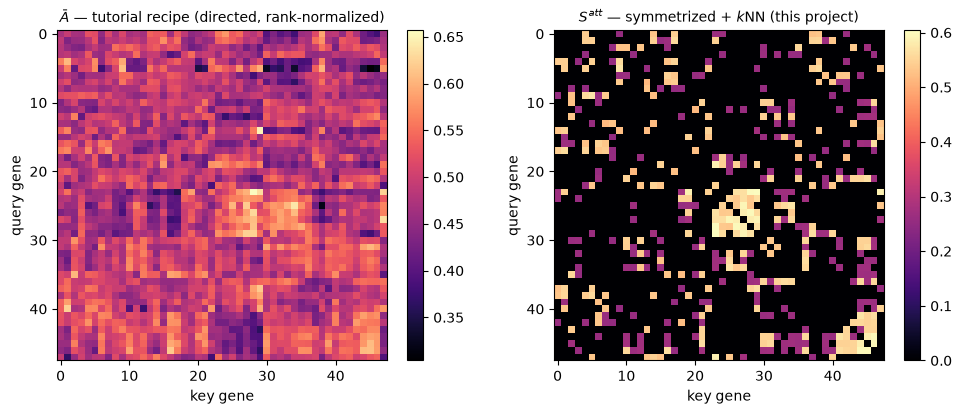

In [5]:
model, _vocab, cfg, report = load_pretrained_scgpt(SCGPT_DIR, device="cpu")
print(report.summary())
print("config:", {k: cfg[k] for k in ("embsize", "nlayers", "nheads", "d_hid")})
print(model.transformer_encoder.layers[-1])

ckpt = torch.load(SCGPT_DIR / "best_model.pt", map_location="cpu", weights_only=True)
wqkv_loaded = all(
    torch.equal(layer.self_attn.in_proj_weight, ckpt[f"transformer_encoder.layers.{i}.self_attn.Wqkv.weight"])
    for i, layer in enumerate(model.transformer_encoder.layers)
)
print("all 12 pretrained Wqkv loaded:", wqkv_loaded)
del ckpt, model

A_bar = priors.attention.meta["raw_attention"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, M, title in [
    (axes[0], A_bar, r"$\bar A$ — tutorial recipe (directed, rank-normalized)"),
    (axes[1], S_att, r"$S^{att}$ — symmetrized + $k$NN (this project)"),
]:
    im = ax.imshow(M, cmap="magma")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("key gene")
    ax.set_ylabel("query gene")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

### Intermediate prior diagnostics

Before the side-by-side heatmaps, inspect **edge-weight scale** and **per-gene degree**.

- If $S_E$ has many mid/high correlations and $S^{att}$ is sparse with a few hubs, they are already different objects.
- Check whether the top $S_E$ edges look like known gene families (e.g. `S100A8–S100A9`) and whether the top $S^{att}$ edges concentrate on a few hub genes.

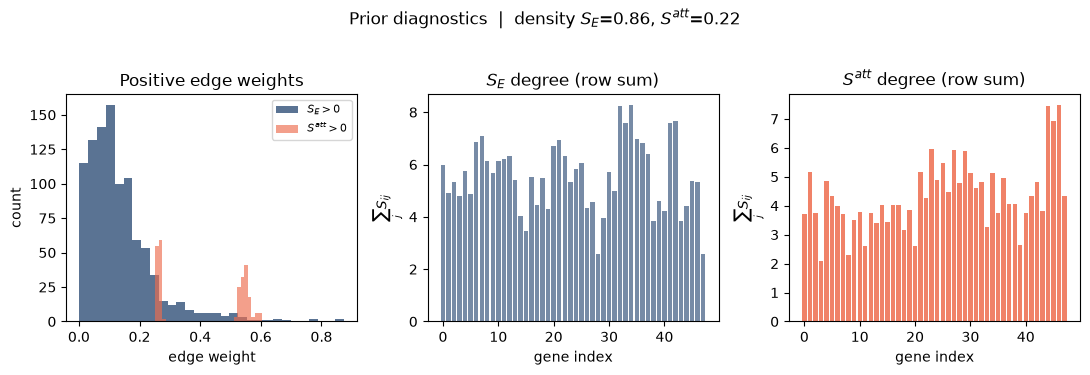

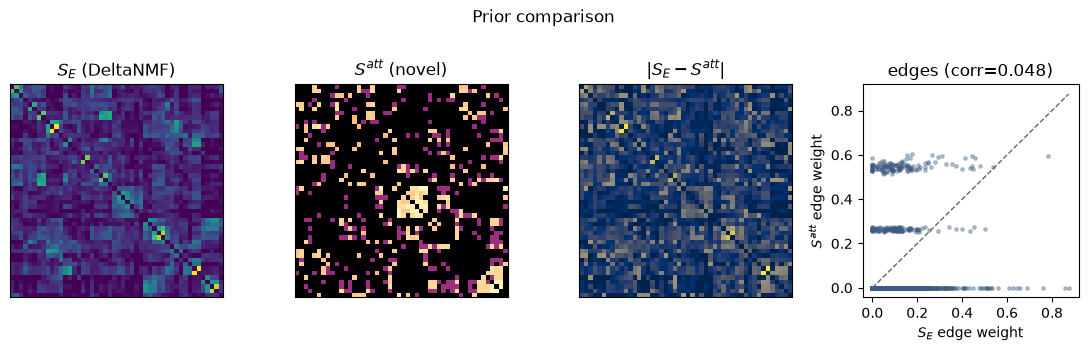

In [6]:
plot_prior_edge_diagnostics(priors)
plt.show()

plot_prior_comparison(priors)
plt.show()

### How to read the prior figures

| Panel | Question it answers |
|---|---|
| Weight histograms / degrees | Are the graphs on comparable scales? Is attention hubby? |
| $S_E$ heatmap | Dense static similarity (DeltaNMF default) |
| $S^{att}$ heatmap | Sparse contextual graph (novel) |
| $|S_E - S^{att}|$ | Where they disagree |
| Edge scatter + corr | Are strong $S_E$ edges also strong in attention? |

A near-zero / negative upper-triangle correlation is evidence that attention is **not** a duplicate of embeddings ([idea.md](../idea.md) §17-B).

### 2b. The gene × gene attention graph, up close

Three $G\times G$ matrices over the same genes, reordered by hierarchical clustering of $S^{att}$ so communities sit in diagonal blocks:

| Matrix | What it is |
|---|---|
| $\bar A$ | Raw cell-averaged attention (tutorial recipe). **Directed**: row = query gene, column = key gene. Dense: every gene attends to every gene. |
| $S^{att}$ | $\tfrac12(\bar A + \bar A^\top)$, then keep each gene's 8 strongest neighbours. **This is the graph.** |
| $L = D - S^{att}$ | The graph Laplacian DeltaNMF builds internally (`third_party/deltanmf/deltanmf/models.py`: `L_S_tensor = D_E - S_E`). Diagonal = weighted degree, off-diagonal = $-S^{att}_{ij}$. This is the only form in which the graph touches NMF. |

The network drawing shows the same $S^{att}$: node = gene, edge width ∝ weight, node size ∝ weighted degree, colour = planted synthetic program (grey = noise-only gene). The planted programs are random gene blocks, so there is no reason for scGPT's biology-driven graph to follow the colours.

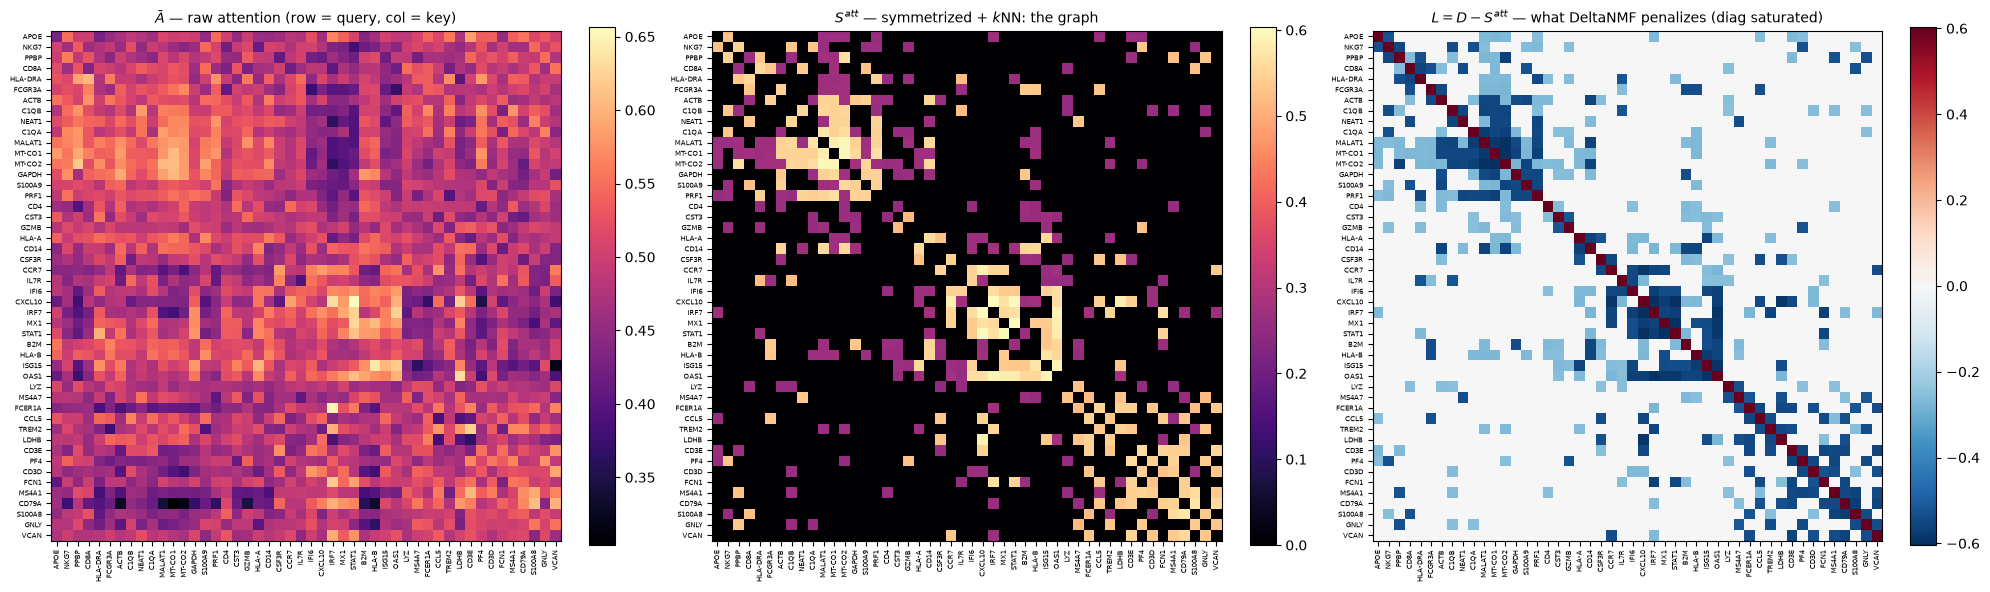

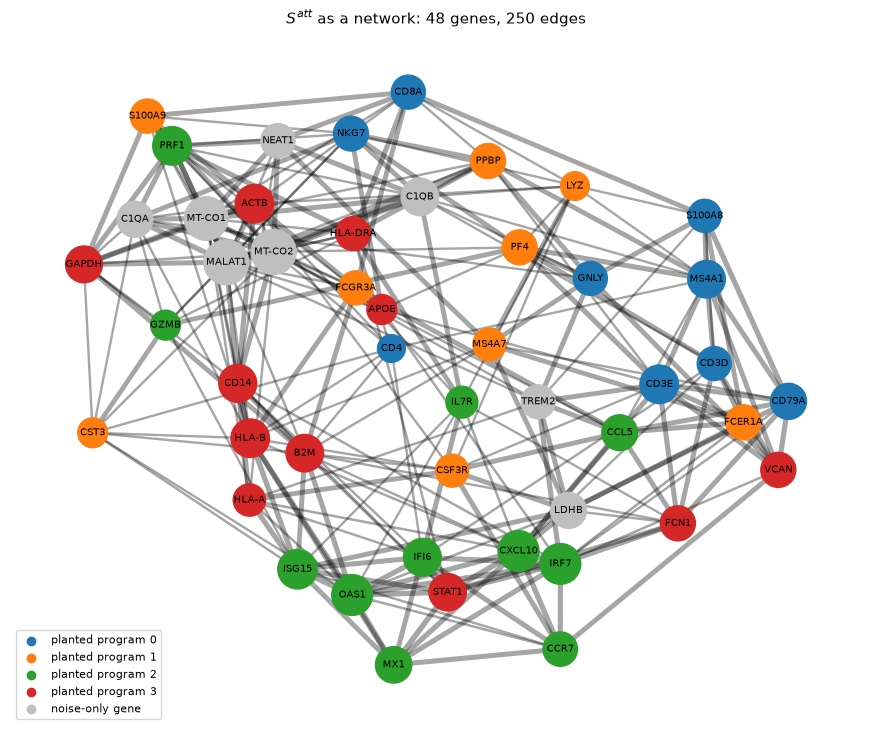

top 10 edges:
  ('CXCL10', 'IRF7', 0.6039540817340214)
  ('CXCL10', 'STAT1', 0.6004995877544085)
  ('MX1', 'STAT1', 0.5972045113643011)
  ('MT-CO1', 'MT-CO2', 0.5949723720550537)
  ('MALAT1', 'MT-CO2', 0.594547192255656)
  ('ISG15', 'OAS1', 0.5927402128775914)
  ('OAS1', 'IRF7', 0.5913052757581074)
  ('CXCL10', 'LDHB', 0.5868409921725591)
  ('CCR7', 'CXCL10', 0.5855123400688171)
  ('MALAT1', 'MT-CO1', 0.5850340276956558)
top 5 hubs (weighted degree): [('MT-CO2', np.float64(7.47)), ('MALAT1', np.float64(7.45)), ('MT-CO1', np.float64(6.94)), ('CXCL10', np.float64(5.95)), ('OAS1', np.float64(5.92))]


In [7]:
genes = priors.gene_names
assert genes == names, "all synthetic genes are in the scGPT vocab, so planted indices line up"
A_bar = priors.attention.meta["raw_attention"]
L_att = graph_laplacian(S_att, normalized=False)

dist = 1.0 - S_att / S_att.max()
np.fill_diagonal(dist, 0.0)
order = leaves_list(linkage(squareform(dist, checks=False), method="average"))
ticks = [genes[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6.8))
off_lim = S_att.max()
for ax, M, title, kw in [
    (axes[0], A_bar, r"$\bar A$ — raw attention (row = query, col = key)", dict(cmap="magma")),
    (axes[1], S_att, r"$S^{att}$ — symmetrized + $k$NN: the graph", dict(cmap="magma")),
    (axes[2], L_att, r"$L = D - S^{att}$ — what DeltaNMF penalizes (diag saturated)",
     dict(cmap="RdBu_r", vmin=-off_lim, vmax=off_lim)),
]:
    im = ax.imshow(M[np.ix_(order, order)], **kw)
    ax.set_xticks(range(len(genes)), ticks, rotation=90, fontsize=5)
    ax.set_yticks(range(len(genes)), ticks, fontsize=5)
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

planted = np.where(atlas.program_W.max(axis=1) > 0, atlas.program_W.argmax(axis=1), -1)
graph = nx.Graph()
graph.add_nodes_from(range(len(genes)))
graph.add_weighted_edges_from(
    (i, j, S_att[i, j]) for i, j in zip(*np.triu_indices(len(genes), k=1)) if S_att[i, j] > 0
)
pos = nx.spring_layout(graph, weight="weight", seed=0, k=0.35)
edge_w = np.array([graph[u][v]["weight"] for u, v in graph.edges])
degree = S_att.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(graph, pos, ax=ax, width=4 * edge_w / edge_w.max(), alpha=0.35)
nx.draw_networkx_nodes(
    graph, pos, ax=ax, node_size=150 + 900 * degree / degree.max(),
    node_color=[plt.cm.tab10(p) if p >= 0 else "0.75" for p in planted],
)
nx.draw_networkx_labels(graph, pos, dict(enumerate(genes)), font_size=7, ax=ax)
for p in range(K):
    ax.scatter([], [], color=plt.cm.tab10(p), label=f"planted program {p}")
ax.scatter([], [], color="0.75", label="noise-only gene")
ax.legend(loc="lower left", fontsize=8)
ax.set_title(f"$S^{{att}}$ as a network: {len(genes)} genes, {graph.number_of_edges()} edges", fontsize=11)
ax.axis("off")
plt.show()

print("top 10 edges:", *top_edges(S_att, genes, k=10), sep="\n  ")
print("top 5 hubs (weighted degree):", [(genes[i], round(degree[i], 2)) for i in np.argsort(degree)[::-1][:5]])

### 2c. Proof that $S^{att}$ really comes from scGPT's attention layer

The checks in §2 show that the right *weights* are loaded. The tests below show that the *numbers in $\bar A$* are the attention of the pretrained model, and nothing else.

**Test 1: forward hooks (is it what the model computes?).** A PyTorch *forward hook* is a callback that fires when a module runs and receives that module's actual input and output tensors. We attach one to the last block's attention module and run scGPT's own encoder pass (`model._encode`, which `TransformerModel.forward` uses), not the `attention_logits` helper that §2 used. From the captured block input we:
- (a) project with `in_proj_weight` (the checkpoint's `Wqkv`), recompute $QK^\top$ → rank-normalize → average, and compare with $\bar A$;
- (b) recompute $\operatorname{softmax}(QK^\top/\sqrt{d})\,V \to$ `out_proj` and compare with the attention module's real output. If (b) matches, the $Q, K$ we read are exactly the ones the model uses to mix information between genes.

The forward pass runs with gradients enabled so PyTorch uses the regular module call rather than its fused inference kernel, which would skip the hook. (a) is therefore not exactly zero: §2 extracted $\bar A$ under `torch.no_grad()`, where the fused kernel rounds slightly differently and flips a few near-tied ranks. Running the §2 helper itself with gradients enabled reproduces $\bar A$ to within the same 2e-3.

**Test 2: knockouts (does it depend on attention weights, and only on them?).** $\bar A$ at block 11 should depend on blocks 0–10 and on block 11's Q/K weights, and on nothing that runs after the logits.
- Randomize block 11's feed-forward `linear1` and `out_proj`. These run after the logits, so $\bar A$ should be **bit-identical**.
- Shuffle the Q/K rows of block 11's `in_proj_weight`. $\bar A$ should change.
- Read block 0 instead of block 11. Depth matters, so the map should differ.

**Test 3: context (does it respond to the cells?).** Compare $\bar A$ from cells that mostly use planted program 0 with $\bar A$ from program-1 cells. $S_E$ cannot change this way, because `model.encoder(gene_ids)` never sees expression values.

`binning` breaks ties between equal values at random, so each map is computed right after `set_seed(42)`, as `extract_scgpt_priors` does.

Test 1 — forward hook on block 11
  (a) max |A_hook - A_bar|                          = 2.02e-03
  (b) max |out_proj(softmax(QK^T/√d)V) - module out| = 1.19e-06


Test 2 — knockouts
  recompute A_bar with this helper   : max diff = 0.00e+00
  randomize block-11 FFN + out_proj : max diff = 0.00e+00 (expect 0)
  shuffle block-11 Q/K weights      : corr with A_bar = -0.133
  block 0 instead of block 11       : corr with A_bar = +0.077


Test 3 — context
  program-0 cells vs program-1 cells: corr = +0.290, max |diff| = 0.287


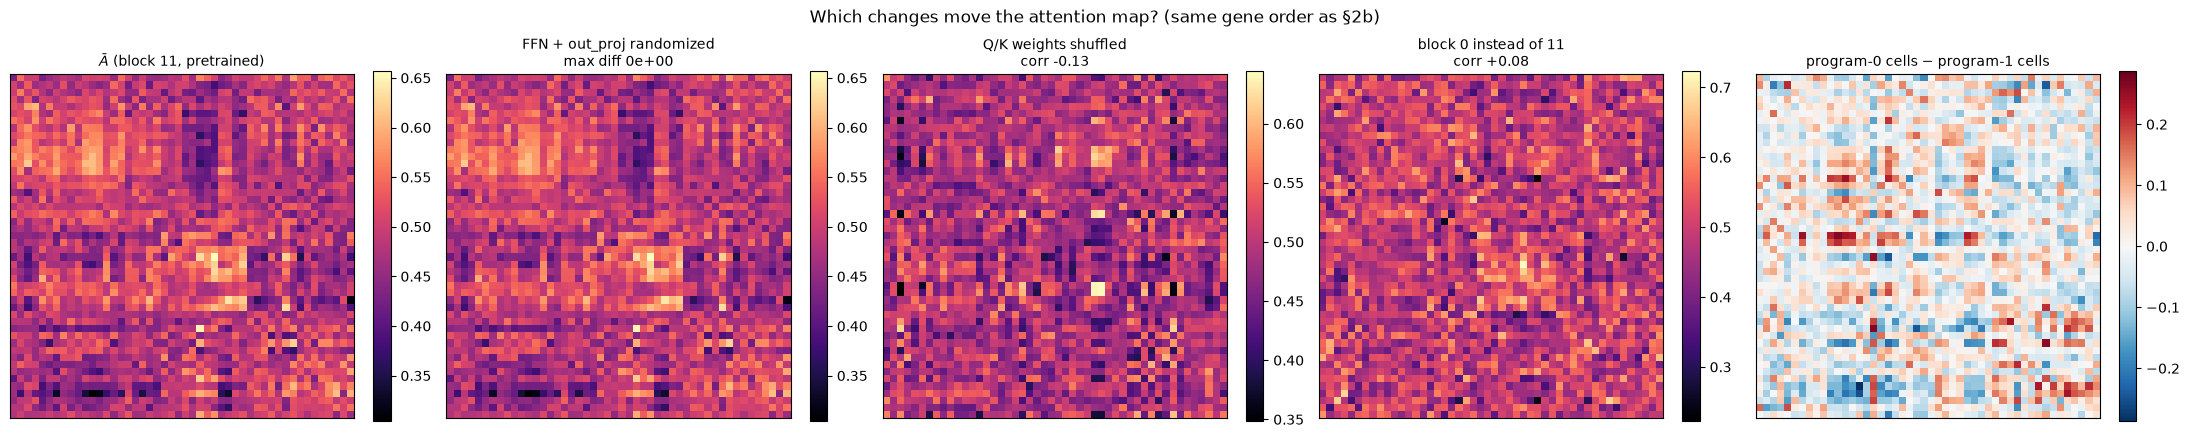

In [8]:
model, vocab, cfg, _ = load_pretrained_scgpt(SCGPT_DIR, device="cpu")
n_bins, pad_value = int(cfg.get("n_bins", 51)), float(cfg.get("pad_value", -2))
n_layers = len(model.transformer_encoder.layers)
X_attn = X[: priors.meta["n_cells_aggregated"]]


def attention_map(m, cells=X_attn, layer=-1):
    set_seed(42)
    return paper_attention_map(
        m, vocab, genes, cells, layer_index=layer % n_layers, n_bins=n_bins, pad_value=pad_value
    )


def corr(a, b):
    return float(np.corrcoef(a.ravel(), b.ravel())[0, 1])


# Test 1 — hook on scGPT's own encoder pass
attn_last = model.transformer_encoder.layers[-1].self_attn
captured = {}
hook = attn_last.register_forward_hook(
    lambda mod, inp, out: captured.update(x=inp[0].detach(), out=out[0].detach())
)
set_seed(42)
ids, values, padding = tokenize_cells(X_attn, genes, vocab, n_bins=n_bins, pad_value=pad_value)
model._encode(ids, values, padding)
hook.remove()
del model.cur_gene_token_embs  # graph-attached cache from _encode; blocks deepcopy in Test 2
with torch.no_grad():
    qkv = F.linear(captured["x"], attn_last.in_proj_weight, attn_last.in_proj_bias)
    q, k, v = rearrange(qkv, "b s (three h d) -> b s three h d", three=3, h=attn_last.num_heads).unbind(dim=2)
    logits = torch.einsum("bshd,bthd->bhst", q, k)
    A_hook = rank_normalize_attention(logits)[:, 1:, 1:].mean(dim=0).numpy()
    probs = torch.softmax(logits / math.sqrt(q.shape[-1]), dim=-1)
    out_manual = attn_last.out_proj(rearrange(torch.einsum("bhst,bthd->bshd", probs, v), "b s h d -> b s (h d)"))

print("Test 1 — forward hook on block 11")
print(f"  (a) max |A_hook - A_bar|                          = {np.abs(A_hook - A_bar).max():.2e}")
print(f"  (b) max |out_proj(softmax(QK^T/√d)V) - module out| = {(out_manual - captured['out']).abs().max():.2e}")


# Test 2 — knockouts on copies of the model
def knockout(edit):
    m = copy.deepcopy(model)
    with torch.no_grad():
        edit(m.transformer_encoder.layers[-1])
    return attention_map(m)


def randomize_post_logit(layer):
    layer.linear1.weight.normal_()
    layer.self_attn.out_proj.weight.normal_()


def shuffle_qk(layer):
    n_qk = 2 * cfg["embsize"]
    W = layer.self_attn.in_proj_weight
    W[:n_qk] = W[:n_qk][torch.randperm(n_qk)]


A_ref = attention_map(model)
torch.manual_seed(0)
A_post = knockout(randomize_post_logit)
A_qk = knockout(shuffle_qk)
A_layer0 = attention_map(model, layer=0)

print("Test 2 — knockouts")
print(f"  recompute A_bar with this helper   : max diff = {np.abs(A_ref - A_bar).max():.2e}")
print(f"  randomize block-11 FFN + out_proj : max diff = {np.abs(A_post - A_ref).max():.2e} (expect 0)")
print(f"  shuffle block-11 Q/K weights      : corr with A_bar = {corr(A_qk, A_ref):+.3f}")
print(f"  block 0 instead of block 11       : corr with A_bar = {corr(A_layer0, A_ref):+.3f}")

# Test 3 — context
primary = atlas.program_H.argmax(axis=1)
A_p0 = attention_map(model, cells=X[primary == 0])
A_p1 = attention_map(model, cells=X[primary == 1])
print("Test 3 — context")
print(f"  program-0 cells vs program-1 cells: corr = {corr(A_p0, A_p1):+.3f}, max |diff| = {np.abs(A_p0 - A_p1).max():.3f}")

diff_lim = np.abs(A_p0 - A_p1).max()
fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
for ax, M, title, kw in [
    (axes[0], A_ref, r"$\bar A$ (block 11, pretrained)", dict(cmap="magma")),
    (axes[1], A_post, f"FFN + out_proj randomized\nmax diff {np.abs(A_post - A_ref).max():.0e}", dict(cmap="magma")),
    (axes[2], A_qk, f"Q/K weights shuffled\ncorr {corr(A_qk, A_ref):+.2f}", dict(cmap="magma")),
    (axes[3], A_layer0, f"block 0 instead of 11\ncorr {corr(A_layer0, A_ref):+.2f}", dict(cmap="magma")),
    (axes[4], A_p0 - A_p1, "program-0 cells − program-1 cells",
     dict(cmap="RdBu_r", vmin=-diff_lim, vmax=diff_lim)),
]:
    im = ax.imshow(M[np.ix_(order, order)], **kw)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Which changes move the attention map? (same gene order as §2b)", fontsize=12)
fig.tight_layout()
plt.show()
del model

## 3. Four DeltaNMF arms

Every arm is one call to DeltaNMF's `run_onestage_deltanmf`, the pipeline behind its `example_scripts/run_onestage.py`. The pipeline:

1. drops genes detected in fewer than `MIN_CELLS` cells;
2. scales each gene to unit variance (`USE_UNITVAR=True`);
3. initializes $W, H$ from consensus NMF (5 runs, Kotliar et al. 2019);
4. optimizes with Adam; the graph term switches on for the last 200 iterations (`FM_LAST_ITERS`), with its weight set so that it equals `rel_alpha` × the reconstruction loss at that moment.

**Only the similarity file handed in as `S_E` changes** ([idea.md](../idea.md) §16).

| Arm | Similarity used | What it tests |
|---|---|---|
| **NMF** | none (`use_fm=False`) | Expression-only baseline |
| **Embedding-NMF** | $S_E$ | Vanilla DeltaNMF |
| **Attention-NMF** | $S^{att}$ | Novel prior |
| **Combined-NMF** | $\alpha S_E + (1-\alpha) S^{att}$ | Complementarity |

Combined prior:

$$
S = \alpha S_E + (1-\alpha) S^{att},
\qquad \alpha \in \{0, 0.25, 0.5, 0.75, 1\}.
$$

Because the graph weight is set relative to the reconstruction loss, the dense $S_E$ and the sparse $S^{att}$ start with the same strength even though their edge weights have different scales.

`recon_mse` = $\mathrm{mean}((\tilde X - WH)^2)$ on DeltaNMF's normalized $\tilde X$. Lower recon means the prior fights the data less — **not** the same as better biology.

Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(


Regularized NTC Discovery:   0%|          | 0/10000 [00:00<?, ?it/s]

DEBUG: Genes after min_cells filter: 48
DEBUG: Genes loaded from S_E_GENES_PATH: 48


Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

...

DEBUG: Genes after min_cells filter: 48
DEBUG: Genes loaded from S_E_GENES_PATH: 48


Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(


Regularized NTC Discovery:   0%|          | 0/10000 [00:00<?, ?it/s]

DeltaNMF run_onestage_deltanmf × {no FM | S_E | S_att | α-mix}
  model                                         recon_mse
  NMF (DeltaNMF, use_fm=False)                   0.164788
  Embedding-NMF (= DeltaNMF S_E)                 0.164794
  Attention-NMF (S_att as S_E)                   0.164791
  Combined-NMF                                   0.164790
  α sweep (Combined; S = α S_E + (1-α) S_att):
    α=0.0    recon_mse=0.164791
    α=0.25   recon_mse=0.164791
    α=0.5    recon_mse=0.164790
    α=0.75   recon_mse=0.164790
    α=1.0    recon_mse=0.164794
  recon_mse is on DeltaNMF's normalized X; a graph prior raises it by design, so it does not rank the priors.


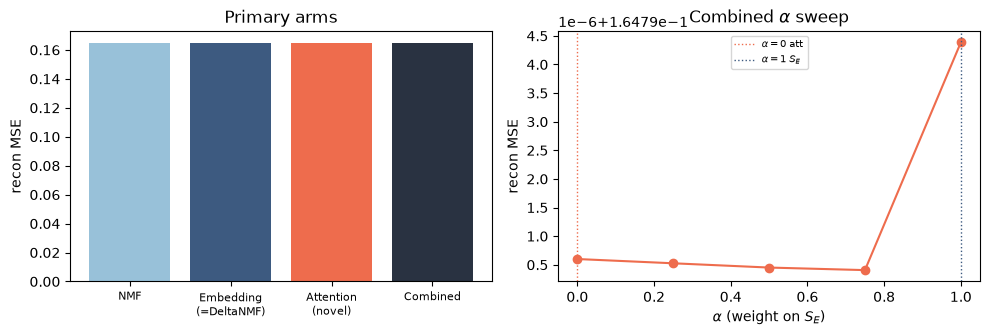

In [9]:
result = run_program_discovery_experiment(
    X, names, priors,
    n_components=K,
    rel_alpha=0.05,   # run_onestage.py: graph term = 5% of recon loss when it switches on
    min_cells=10,     # run_onestage.py
    max_iter=10000,   # run_onestage_deltanmf default
    primary_alpha=0.5,
    alphas=DEFAULT_ALPHAS,
)
print(format_comparison(result))

plot_recon_comparison(result)
plt.show()

### How to read the recon figure

Three pairwise questions ([idea.md](../idea.md) §5):

1. **NMF → Embedding** — does DeltaNMF’s $S_E$ help fit? (often recon rises because the graph constrains $W$)
2. **Embedding → Attention** — does contextual $S^{att}$ behave differently?
3. **Attention → Combined ($\alpha$ sweep)** — is there a sweet spot, or does adding $S_E$ only interpolate toward Embedding?

On synthetic data, treat this as a **feasibility / sensitivity** readout.

### 3b. Is the graph applied to the data?

During its last 200 iterations, DeltaNMF (`models.solve_ntc_regularized`) minimizes, by Adam on $W, H \ge 0$:

$$
\underbrace{\tfrac{1}{GN}\lVert \tilde X - WH\rVert_F^2}_{\texttt{recon\_loss}}
\;+\;
\underbrace{\alpha_{ntc}\,\tfrac{1}{GK}\operatorname{Tr}(W^\top L W)}_{\texttt{fm\_loss}},
\qquad
\operatorname{Tr}(W^\top L W)=\tfrac12\sum_{i,j} S_{ij}\,\lVert w_i - w_j\rVert^2 ,
$$

with $L = D - S$ and $\alpha_{ntc}$ chosen so that `fm_loss` = `rel_alpha` × `recon_loss` when the term switches on. $w_i$ is gene $i$'s row of $W$ (its loadings across the $K$ programs). The penalty grows when two genes joined by a strong edge get different loadings, so it pulls graph neighbours toward the same programs. $\tilde X$ enters only the first term and the graph only the second, so the graph acts on the data indirectly, by making some factorizations cheaper than others.

Two checks:

1. **Is each arm smoothest on its own graph?** `graph_smoothness(W, S)` = mean Rayleigh quotient $\tilde w^\top L \tilde w / \tilde w^\top \tilde w$ over mean-centred columns $\tilde w$ (lower = smoother on that graph).
2. **Dose-response with a shuffled-graph control.** Increase `rel_alpha`. If the specific gene pairings in $S^{att}$ matter, the Attention-NMF $W$ should get smoother on $S^{att}$ but not on *shuffled* copies of $S^{att}$ (same weights and degree distribution, gene labels permuted), and a fit on a shuffled graph should not get smoother on the real $S^{att}$.

Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(


Regularized NTC Discovery:   0%|          | 0/10000 [00:00<?, ?it/s]

Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(


...

DEBUG: Genes after min_cells filter: 48
DEBUG: Genes loaded from S_E_GENES_PATH: 48


Consensus Runs:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1207: RuntimeWarning: When update_H=False, the provided initial W is not used.
  warnings.warn(
/Users/albert/Documents/attention/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 50 reached. Increase it to improve convergence.
  warnings.warn(


Regularized NTC Discovery:   0%|          | 0/10000 [00:00<?, ?it/s]

arm × graph smoothness (lower = smoother)
  arm         on S_att    on S_E
  NMF            3.699     5.159
  Embedding      3.698     5.158
  Attention      3.695     5.159
  Combined       3.697     5.159

dose-response
  rel_alpha  Att-fit on S_att  Att-fit on shuffled  shuffled-fit on S_att    recon
       0.00             3.699                4.384                  3.699   0.1648
       0.05             3.695                4.384                  3.698   0.1648
       0.20             3.684                4.385                  3.697   0.1648
       0.50             3.670                4.384                  3.688   0.1649
       1.00             3.657                4.383                  3.684   0.1651


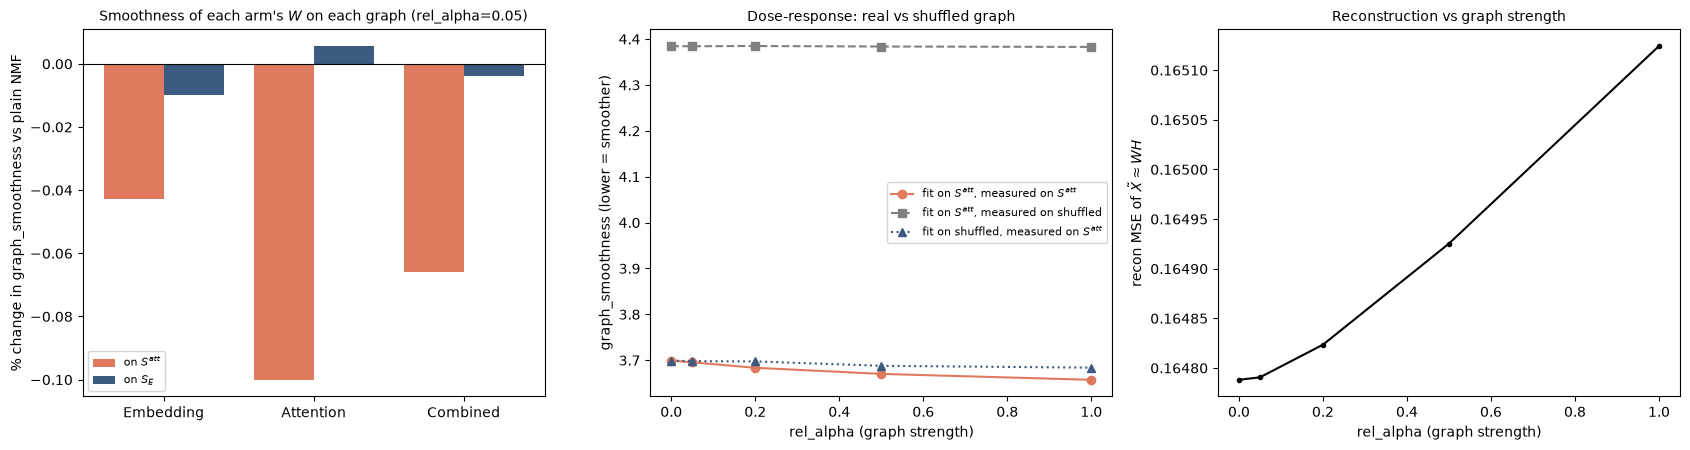

In [10]:
X_gc = X.T.astype(np.float32)   # DeltaNMF orientation: genes × cells
rng = np.random.default_rng(0)
S_shuffled = [S_att[np.ix_(p, p)] for p in (rng.permutation(len(genes)) for _ in range(5))]

arms = [result.nmf, result.embedding, result.attention, result.combined]
arm_labels = ["NMF", "Embedding", "Attention", "Combined"]
assert all(a.fit.gene_names == genes for a in arms), "DeltaNMF's MIN_CELLS filter dropped genes"
smooth = np.array([[graph_smoothness(a.fit.W, S_att), graph_smoothness(a.fit.W, S_E)] for a in arms])

rel_alphas = [0.0, 0.05, 0.2, 0.5, 1.0]
dose = []
for a in rel_alphas:
    fit_att = fit_deltanmf(X_gc, genes, S_att, K=K, rel_alpha=a)
    fit_shuf = fit_deltanmf(X_gc, genes, S_shuffled[0], K=K, rel_alpha=a)
    dose.append((
        graph_smoothness(fit_att.W, S_att),
        np.mean([graph_smoothness(fit_att.W, S) for S in S_shuffled[1:]]),
        graph_smoothness(fit_shuf.W, S_att),
        fit_att.recon,
    ))
dose = np.array(dose)

print("arm × graph smoothness (lower = smoother)")
print(f"  {'arm':<10} {'on S_att':>9} {'on S_E':>9}")
for lbl, (s_att, s_e) in zip(arm_labels, smooth):
    print(f"  {lbl:<10} {s_att:9.3f} {s_e:9.3f}")
print("\ndose-response")
print(f"  {'rel_alpha':>9} {'Att-fit on S_att':>17} {'Att-fit on shuffled':>20} {'shuffled-fit on S_att':>22} {'recon':>8}")
for a, row in zip(rel_alphas, dose):
    print(f"  {a:9.2f} {row[0]:17.3f} {row[1]:20.3f} {row[2]:22.3f} {row[3]:8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
rel = 100 * (smooth / smooth[0] - 1)
x = np.arange(1, len(arms))
ax.bar(x - 0.2, rel[1:, 0], 0.4, label=r"on $S^{att}$", color="#e07a5f")
ax.bar(x + 0.2, rel[1:, 1], 0.4, label=r"on $S_E$", color="#3d5a80")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, arm_labels[1:])
ax.set_ylabel("% change in graph_smoothness vs plain NMF")
ax.set_title("Smoothness of each arm's $W$ on each graph (rel_alpha=0.05)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(rel_alphas, dose[:, 0], "o-", color="#e07a5f", label=r"fit on $S^{att}$, measured on $S^{att}$")
ax.plot(rel_alphas, dose[:, 1], "s--", color="0.5", label=r"fit on $S^{att}$, measured on shuffled")
ax.plot(rel_alphas, dose[:, 2], "^:", color="#3d5a80", label=r"fit on shuffled, measured on $S^{att}$")
ax.set_xlabel("rel_alpha (graph strength)")
ax.set_ylabel("graph_smoothness (lower = smoother)")
ax.set_title("Dose-response: real vs shuffled graph", fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(rel_alphas, dose[:, 3], "k.-")
ax.set_xlabel("rel_alpha (graph strength)")
ax.set_ylabel(r"recon MSE of $\tilde X \approx WH$")
ax.set_title("Reconstruction vs graph strength", fontsize=10)
fig.tight_layout()
plt.show()

### Reading §3b

Read the signs off the printed tables above; on synthetic data they can go either way.

- **Arm bars.** A negative bar means that arm's $W$ is smoother on that graph than plain NMF's. If Attention-NMF is smoother on $S^{att}$ but not on $S_E$, and Embedding-NMF shows the reverse, each prior is pushing $W$ toward its own graph and not the other's.
- **Dose-response.** If the specific gene pairings in $S^{att}$ matter, the orange line falls as `rel_alpha` grows while the grey and blue lines stay flat. If all three fall together, the effect is generic smoothing rather than scGPT's pairings. `rel_alpha=0` is the plain-NMF fit, so all lines start from the same $W$.
- **Reconstruction.** A stronger graph usually costs reconstruction. Choose `rel_alpha` on held-out data, not by eye.

## 4. Do the recovered *programs* change?

Recon alone is insufficient. NMF factors are defined up to **column permutation**, so we greedily align non-Embedding arms to Embedding-NMF by absolute column correlation before plotting.

We look at four views:

1. **$W$ heatmaps** — gene loadings for all four arms
2. **Arm similarity matrix** — mean $|$corr$|$ of aligned $W$ columns
3. **Top genes** — Embedding vs Attention, per program
4. **$H$ heatmaps** — cell usage of programs

W shapes: {'NMF (DeltaNMF, use_fm=False)': (48, 4), 'Embedding-NMF (= DeltaNMF S_E)': (48, 4), 'Attention-NMF (S_att as S_E)': (48, 4), 'Combined-NMF': (48, 4)}
H shapes: {'NMF (DeltaNMF, use_fm=False)': (4, 80), 'Embedding-NMF (= DeltaNMF S_E)': (4, 80), 'Attention-NMF (S_att as S_E)': (4, 80), 'Combined-NMF': (4, 80)}


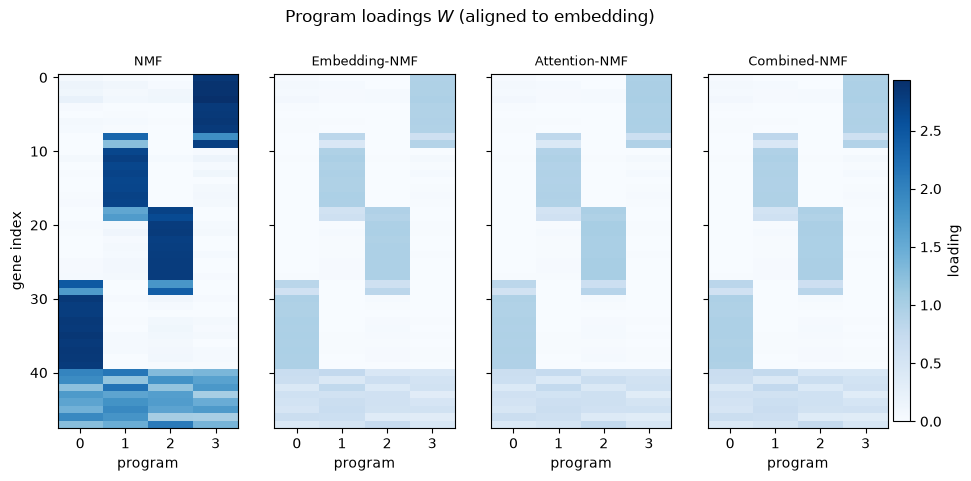

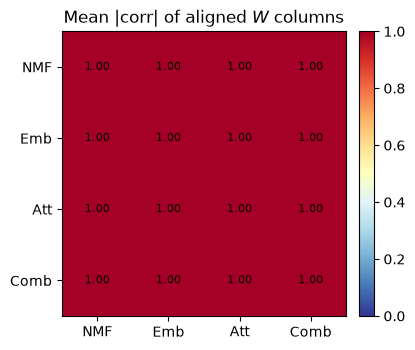

In [11]:
print("W shapes:", {arm.name: arm.fit.W.shape for arm in [
    result.nmf, result.embedding, result.attention, result.combined
]})
print("H shapes:", {arm.name: arm.fit.H.shape for arm in [
    result.nmf, result.embedding, result.attention, result.combined
]})

plot_program_loadings(result, priors.gene_names, align_to="embedding")
plt.show()

plot_arm_W_similarity(result)
plt.show()

### Reading $W$ + similarity

- If Attention and Embedding heatmaps look nearly identical and the similarity matrix is ~0.97–1.0, the novel prior **did not materially change programs** on this matrix (even if recon differs slightly).
- If blocks shift or the Att↔Emb entry drops, the prior is doing real work on $W$.

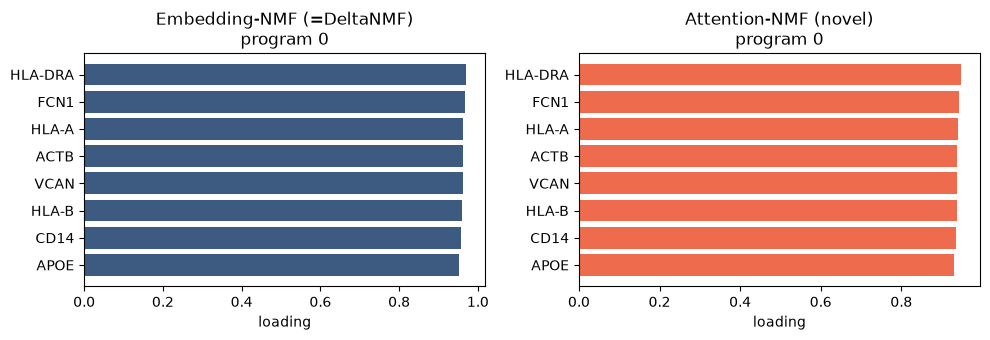

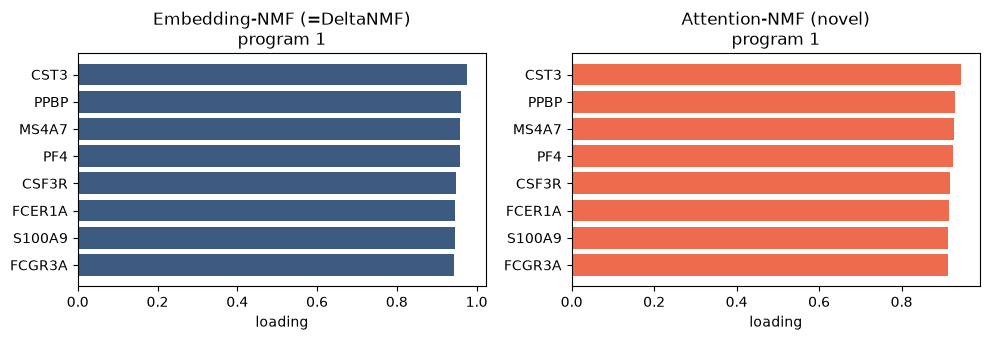

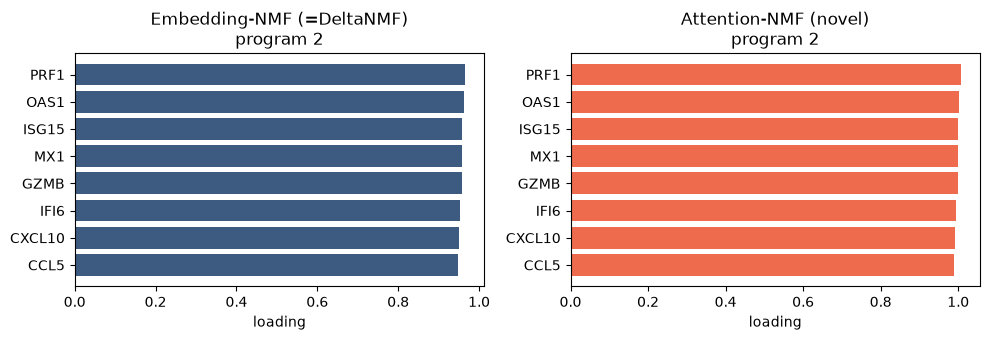

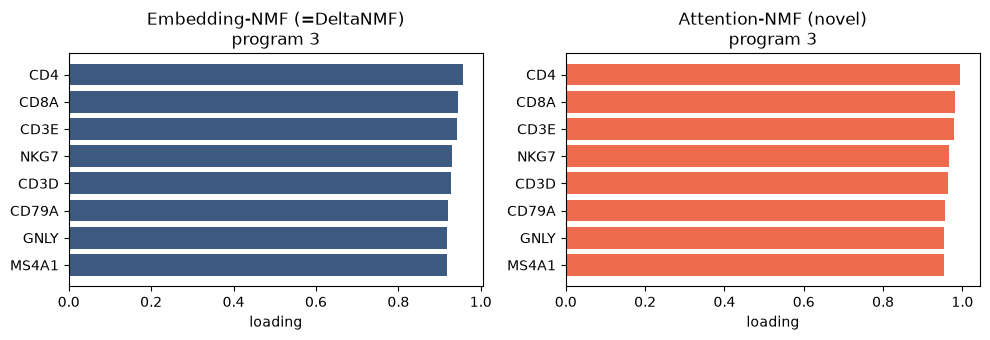

In [12]:
# Top genes for every program: Embedding (blue) vs Attention (orange).
# Same rank order ⇒ programs agree; swaps in the tail ⇒ mild disagreement.
for prog in range(K):
    plot_top_genes_comparison(result, priors.gene_names, program=prog, top_n=8)
    plt.show()

### Cell-level program usage ($H$)

$H$ says **which cells use which programs**. Attention’s $H$ is row-aligned to Embedding via the same permutation used for $W$, so differences are content, not reordering.

On the synthetic atlas you should still see the planted block / step structure; compare whether Attention smooths or reshapes those blocks relative to Embedding.

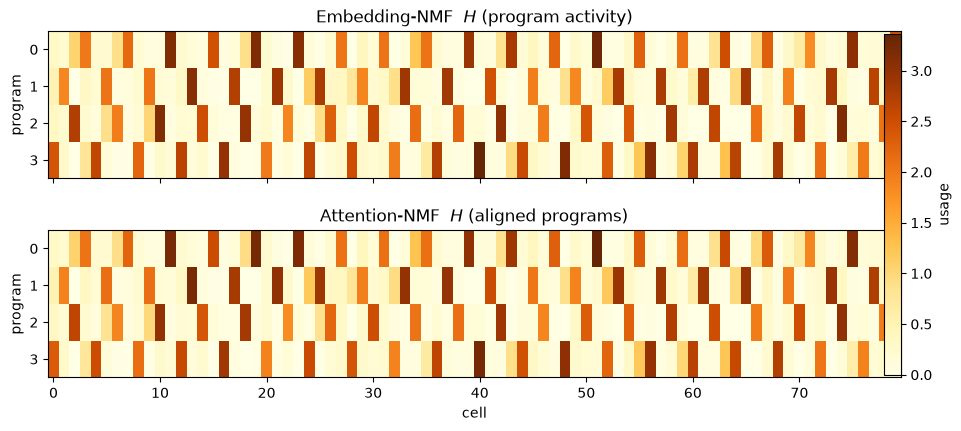

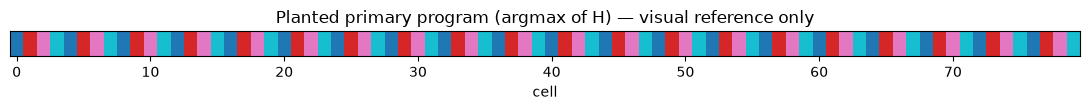

In [13]:
plot_cell_program_usage(result, max_cells=N_CELLS)
plt.show()

# Optional: overlay planted primary program per cell as a reference strip.
primary = atlas.program_H.argmax(axis=1)
fig, ax = plt.subplots(figsize=(11, 1.2))
ax.imshow(primary[None, :], aspect="auto", cmap="tab10", vmin=0, vmax=max(K - 1, 1))
ax.set_yticks([])
ax.set_xlabel("cell")
ax.set_title("Planted primary program (argmax of H) — visual reference only")
fig.tight_layout()
plt.show()

## 5. How to read everything together

| Figure | Question |
|---|---|
| Atlas / $X$ histograms | Is the input well-formed? |
| Prior diagnostics + heatmaps + scatter | Does $S^{att}$ differ from DeltaNMF $S_E$? ([idea.md](../idea.md) §17-B) |
| Recon bars / $\alpha$ sweep | Does the attention prior change fit quality? (§17-C) |
| $W$ heatmaps + similarity matrix | Do programs *themselves* change, not just recon? |
| Top-gene bars | Which genes move between Embedding vs Attention? |
| $H$ heatmaps + planted strip | Does cell usage of programs shift? |

### What this notebook is *not*

- Not a claim that attention improves biological coherence on real tissue.
- Not Stage-2 condition-specific $\Delta S$ ([idea.md](../idea.md) §14).

## Next

1. Real AnnData in place of the synthetic atlas.
2. Layer / $k$ ablations for attention only.
3. Condition-specific $S^{att}$.